In [529]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [530]:
data=pd.read_csv('Ice_cream selling data.csv')
data.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [531]:
x=data.iloc[:,:1]
y=data.iloc[:,1:]

In [532]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=.2,random_state=0)

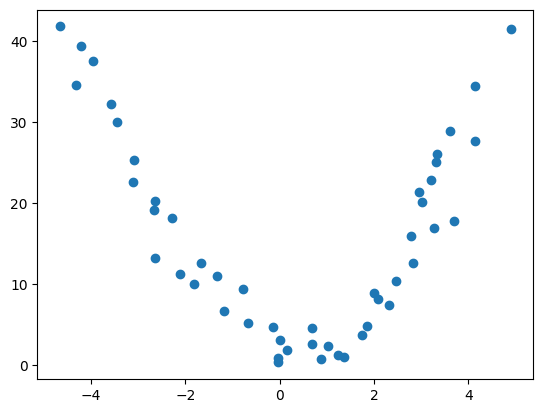

In [533]:
plt.scatter(x,y)

In [534]:
poly=PolynomialFeatures(degree=10,include_bias=False)
x_poly_train=poly.fit_transform(xtrain)
x_ploy_test=poly.transform(xtest)

In [535]:
model=LinearRegression()
model.fit(x_poly_train,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


c:\Users\COMPUMARTS\Downloads\DEPI\Depi_Amit_BNS3_AIS4_S1\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


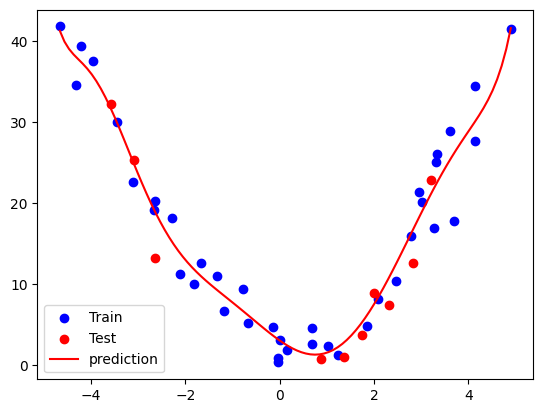

In [536]:
xrange = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
xrangepoly = poly.transform(xrange)

plt.scatter(xtrain, ytrain, color='blue',label='Train')
plt.scatter(xtest,ytest,color='red',label='Test')

plt.plot(xrange,model.predict(xrangepoly),color='red',label='prediction')


plt.legend()
plt.show()

In [537]:
mse=mean_squared_error(ytrain,model.predict(x_poly_train))
mse

6.7051960769368355

In [538]:
mse_t=mean_squared_error(ytest,model.predict(poly.transform(xtest)))
mse_t

7.441130982071348

In [539]:
rmse=np.sqrt(mse)
rmse

np.float64(2.589439336407948)

In [540]:
r2=r2_score(ytrain,model.predict(x_poly_train))
print(f'r2 = {r2}')

r2 = 0.9567935308609091


In [541]:
r2_t=r2_score(ytest,model.predict(poly.transform(xtest)))
print(f'r2 test = {r2_t}')

r2 test = 0.9290235936646001


In [542]:
# To calculate the percentage difference between test and train MSE, this formula is correct:
percentage_difference = ((r2 - r2_t) / r2) * 100
print(f'% r2 = {percentage_difference}')

% r2 = 2.9023960029623166


In [543]:
# To calculate the percentage difference between test and train MSE, this formula is correct:
percentage_difference = ((mse_t - mse) / mse) * 100
percentage_difference

10.97559111904022

**New value Prediction**

In [544]:
xnew=np.array([[1.999310]])
xnewpoly=poly.transform(xnew)
model.predict(xnewpoly)

c:\Users\COMPUMARTS\Downloads\DEPI\Depi_Amit_BNS3_AIS4_S1\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[7.53243316]])

In [545]:
data.tail(20)

,Temperature (°C),Ice Cream Sales (units)
29,1.359813,0.953115
30,1.740000,3.782570
31,1.850552,4.857988
32,1.999310,8.943823
33,2.075101,8.170735
34,2.318591,7.412094
35,2.471946,10.336631
36,2.784836,15.996620
37,2.831760,12.568237
38,2.959932,21.342916
